# Initial Modeling Results

This notebook only **loads and displays saved results**. It trains nothing, evaluates nothing and imports no modeling library.

**Stage 1: Initial Modeling** - Historical Median Baseline, Initial XGBoost, Initial CatBoost, Initial MLP (sections 1-6).
**Stage 2: Hyperparameter Tuning - Work in Progress** (section 7) is shown separately and is not finished.

Models were trained on natural `ln(price)` and converted back with `exp` (not `expm1`). **MAE (SAR) is the primary metric; R² on the original SAR scale is the main R²; R² on `ln(price)` is a supporting diagnostic** (empty where it was never computed).

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

# Locate the repository root from any working directory (this notebook lives in notebooks/).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'src').is_dir() and (p / 'requirements.txt').exists())
INIT = ROOT / 'outputs' / 'initial_models'
TUNE = ROOT / 'outputs' / 'tuning'
TABLES, FIGS = INIT / 'tables', INIT / 'figures'
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

val = pd.read_csv(TABLES / 'initial_validation_comparison.csv')
test = pd.read_csv(TABLES / 'initial_test_comparison.csv')
per_type = pd.read_csv(TABLES / 'initial_per_property_type_test_metrics.csv')
fit = pd.read_csv(TABLES / 'initial_overfitting_check.csv')
history = pd.read_csv(TABLES / 'mlp_training_history.csv')
summary = json.loads((TABLES / 'model_selection_summary.json').read_text(encoding='utf-8'))
frozen = json.loads((INIT / 'models/frozen_configs.json').read_text(encoding='utf-8'))
legacy = {'XGBoost': 'Initial XGBoost', 'CatBoost': 'Initial CatBoost', 'MLP': 'Initial MLP'}   # names in older saved files
fit['Model'] = fit['Model'].replace(legacy)
print('Loaded saved results. Initial models frozen at (UTC):', frozen['frozen_at_utc'])

Loaded saved results. Initial models frozen at (UTC): 2026-09-19T06:47:32+00:00


## 1. Validation 2024 comparison (Initial Modeling)
Improvement = (baseline MAE - model MAE) / baseline MAE x 100.

In [2]:
val.drop(columns='Iteration detail')

,Model,Version,Rank (Validation MAE),Validation MAE (SAR),Validation RMSE (SAR),Validation R2 (SAR),Validation R2 (ln price),Median abs error (SAR),Training time (s),Best iteration / epochs,MAE improvement vs baseline (%),Met 15% target
0,Historical Median Baseline,Baseline,NaN,"663,987.7445","8,648,982.0274",0.0619,NaN,NaN,0.2522,NaN,0.0000,n/a (reference)
1,Initial XGBoost,Initial,1.0000,"539,630.0420","8,261,631.7250",0.1440,0.7132,"117,989.8532",43.9214,"1,229.0000",18.7289,Yes
2,Initial CatBoost,Initial,2.0000,"554,411.0805","7,638,328.8945",0.2683,0.7019,"130,865.1861",437.2944,986.0000,16.5028,Yes
3,Initial MLP,Initial,3.0000,"977,812.5063","24,512,976.0190",-6.5355,NaN,NaN,34.0810,13.0000,-47.2636,No


In [3]:
lines = []
for _, r in val.iloc[1:].sort_values('Validation MAE (SAR)').iterrows():
    verdict = 'meets' if r['Met 15% target'] == 'Yes' else 'does not meet'
    lines.append(f"- **{r['Model']}** (rank {int(r['Rank (Validation MAE)'])}): MAE {r['Validation MAE (SAR)']:,.0f} SAR, "
                 f"{r['MAE improvement vs baseline (%)']:.1f}% vs baseline, so it **{verdict}** the 15% target; "
                 f"R\u00b2 (SAR) {r['Validation R2 (SAR)']:.3f}; training time {r['Training time (s)']:.0f}s ({r['Iteration detail']}).")
display(Markdown('\n'.join(lines)))

- **Initial XGBoost** (rank 1): MAE 539,630 SAR, 18.7% vs baseline, so it **meets** the 15% target; R² (SAR) 0.144; training time 44s (1229 trees kept (early stopping)).
- **Initial CatBoost** (rank 2): MAE 554,411 SAR, 16.5% vs baseline, so it **meets** the 15% target; R² (SAR) 0.268; training time 437s (986 trees kept (early stopping)).
- **Initial MLP** (rank 3): MAE 977,813 SAR, -47.3% vs baseline, so it **does not meet** the 15% target; R² (SAR) -6.536; training time 34s (13 epochs completed (best epoch 5, weights restored)).

### Train vs validation (SAR scale)

In [4]:
fit

,Model,Train MAE (SAR),Validation MAE (SAR),Validation/Train MAE ratio,Train R2,Validation R2
0,Initial XGBoost,"311,219.0615","539,630.0420",1.7339,0.6703,0.1440
1,Initial CatBoost,"351,976.6981","554,411.0805",1.5751,0.4238,0.2683
2,Initial MLP,"566,867.4956","977,812.5063",1.7249,-1.2049,-6.5355


## 2. Test 2025 comparison (Initial Modeling; each initial model evaluated once)

In [5]:
test.drop(columns='Iteration detail')

,Model,Version,Test MAE (SAR),Test RMSE (SAR),Test R2 (SAR),Test R2 (ln price),Median abs error (SAR),Training time (s),Best iteration / epochs,MAE improvement vs baseline (%),Met 15% target
0,Historical Median Baseline,Baseline,"679,495.9399","9,480,146.8916",0.0204,NaN,NaN,0.3013,NaN,0.0000,n/a (reference)
1,Initial XGBoost,Initial — Untuned,"596,077.3127","12,670,755.7478",-0.7500,0.6497,"130,468.5570",43.9214,"1,229.0000",12.2765,No
2,Initial CatBoost,Initial — Untuned,"554,819.4782","7,609,559.6728",0.3688,0.6445,"132,480.2527",437.2944,986.0000,18.3484,Yes
3,Initial MLP,Initial — Untuned,"1,186,305.5068","29,871,336.0617",-8.7260,NaN,NaN,34.0810,13.0000,-74.5861,No


In [6]:
models_t = test.iloc[1:]
best_val, best_test = legacy.get(summary['best_by_validation_mae'], summary['best_by_validation_mae']), legacy.get(summary['best_by_test_mae'], summary['best_by_test_mae'])
lines = [f"- Best initial model by **Validation** MAE: **{best_val}**.", f"- Best initial model by **Test** MAE: **{best_test}**."]
for _, r in models_t.iterrows():
    v = val.loc[val['Model'] == r['Model'], 'Validation MAE (SAR)'].iloc[0]
    lines.append(f"- {r['Model']}: test MAE {r['Test MAE (SAR)']:,.0f} vs validation MAE {v:,.0f} "
                 f"({(r['Test MAE (SAR)'] / v - 1) * 100:+.1f}%); {r['MAE improvement vs baseline (%)']:.1f}% vs test baseline "
                 f"-> 15% target {'met' if r['Met 15% target'] == 'Yes' else 'not met'}; test R\u00b2 (SAR) {r['Test R2 (SAR)']:.3f}.")
display(Markdown('\n'.join(lines)))

- Best initial model by **Validation** MAE: **Initial XGBoost**.
- Best initial model by **Test** MAE: **Initial CatBoost**.
- Initial XGBoost: test MAE 596,077 vs validation MAE 539,630 (+10.5%); 12.3% vs test baseline -> 15% target not met; test R² (SAR) -0.750.
- Initial CatBoost: test MAE 554,819 vs validation MAE 554,411 (+0.1%); 18.3% vs test baseline -> 15% target met; test R² (SAR) 0.369.
- Initial MLP: test MAE 1,186,306 vs validation MAE 977,813 (+21.3%); -74.6% vs test baseline -> 15% target not met; test R² (SAR) -8.726.

## 3. Comparison plots (initial-model figures)

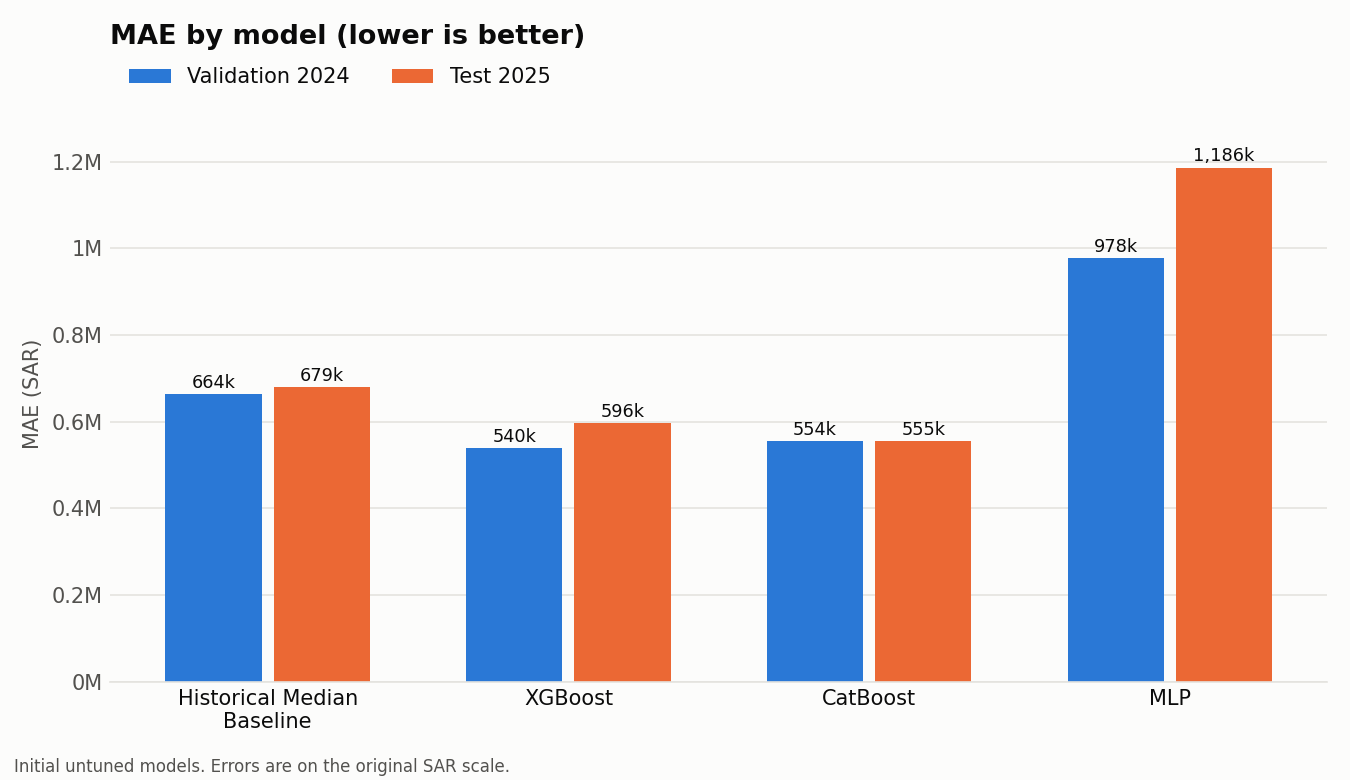

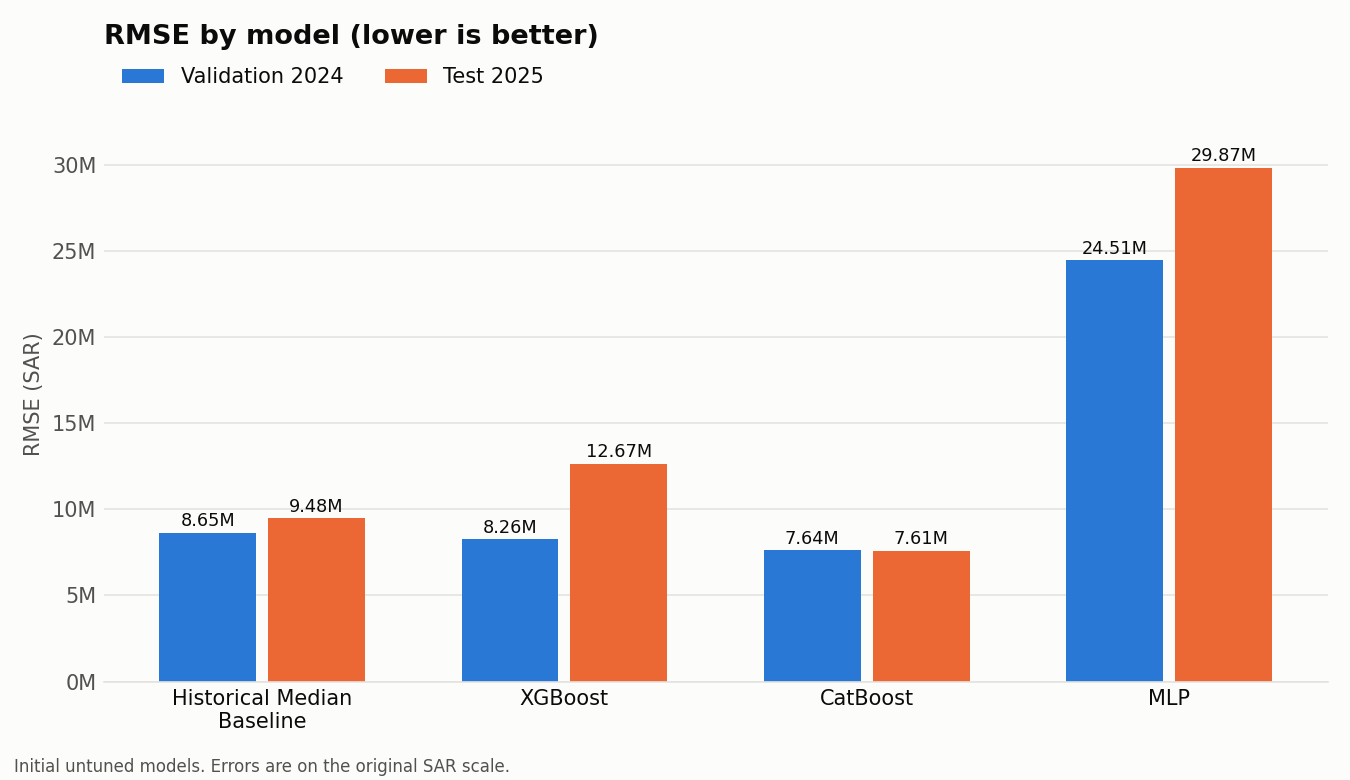

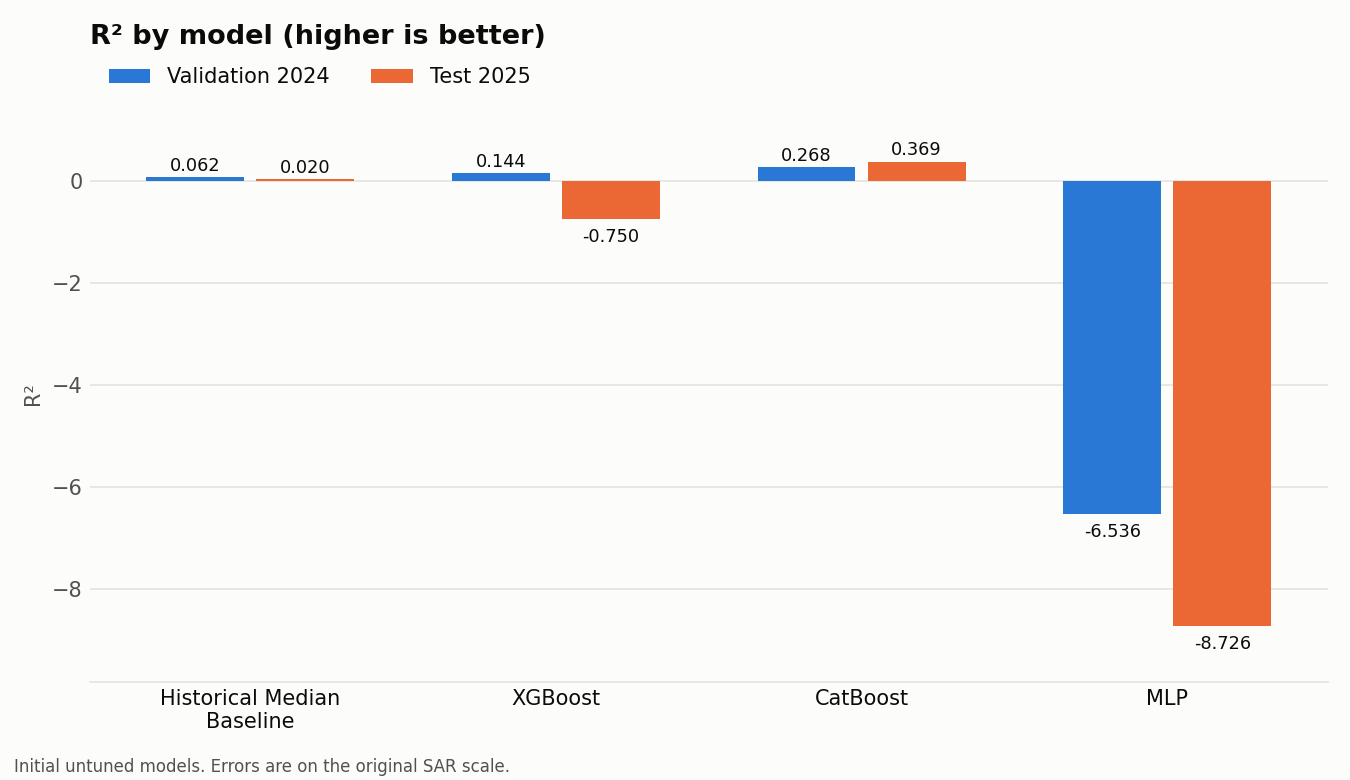

In [7]:
for name in ['model_comparison_mae', 'model_comparison_rmse', 'model_comparison_r2']:
    display(Image(filename=str(FIGS / f'{name}.png'), width=760))

## 4. Test results by property type

In [8]:
per_type.drop(columns='R2 note')

,Model,Property type,Test rows,MAE (SAR),RMSE (SAR),R2
0,Historical Median Baseline,Residential,181503,"480,021.6273","5,258,114.1396",0.0055
1,Historical Median Baseline,Commercial,12180,"3,231,369.4436","31,822,427.5326",0.0207
2,Historical Median Baseline,Agricultural,6255,"1,498,579.3729","9,928,843.1205",-0.0699
3,Initial XGBoost,Residential,181503,"381,752.4064","4,612,771.1756",0.2346
4,Initial XGBoost,Commercial,12180,"3,363,115.8200","47,703,108.0357",-1.2005
5,Initial XGBoost,Agricultural,6255,"1,427,106.0025","9,126,990.6689",0.0960
6,Initial CatBoost,Residential,181503,"388,363.7656","4,602,816.8419",0.2379
7,Initial CatBoost,Commercial,12180,"2,702,117.0510","24,344,781.2554",0.4269
8,Initial CatBoost,Agricultural,6255,"1,203,600.7367","9,060,417.0496",0.1091
9,Initial MLP,Residential,181503,"608,050.8995","10,611,073.1659",-3.0501


In [9]:
notes = per_type[per_type['R2 note'].notna()][['Model', 'Property type', 'R2 note']]
if len(notes):
    display(notes)
else:
    display(Markdown('R\u00b2 was defined and based on at least 30 rows for every model and property type.'))
only_models = per_type[per_type['Model'] != 'Historical Median Baseline']
best = only_models.loc[only_models.groupby('Property type')['MAE (SAR)'].idxmin()]
display(Markdown('Lowest test MAE per property type (initial models only): ' + '; '.join(
    f"**{r['Property type']}** - {r['Model']} ({r['MAE (SAR)']:,.0f} SAR, n={r['Test rows']:,})" for _, r in best.iterrows())))

R² was defined and based on at least 30 rows for every model and property type.

Lowest test MAE per property type (initial models only): **Agricultural** - Initial CatBoost (1,203,601 SAR, n=6,255); **Commercial** - Initial CatBoost (2,702,117 SAR, n=12,180); **Residential** - Initial XGBoost (381,752 SAR, n=181,503)

## 5. Initial MLP training history

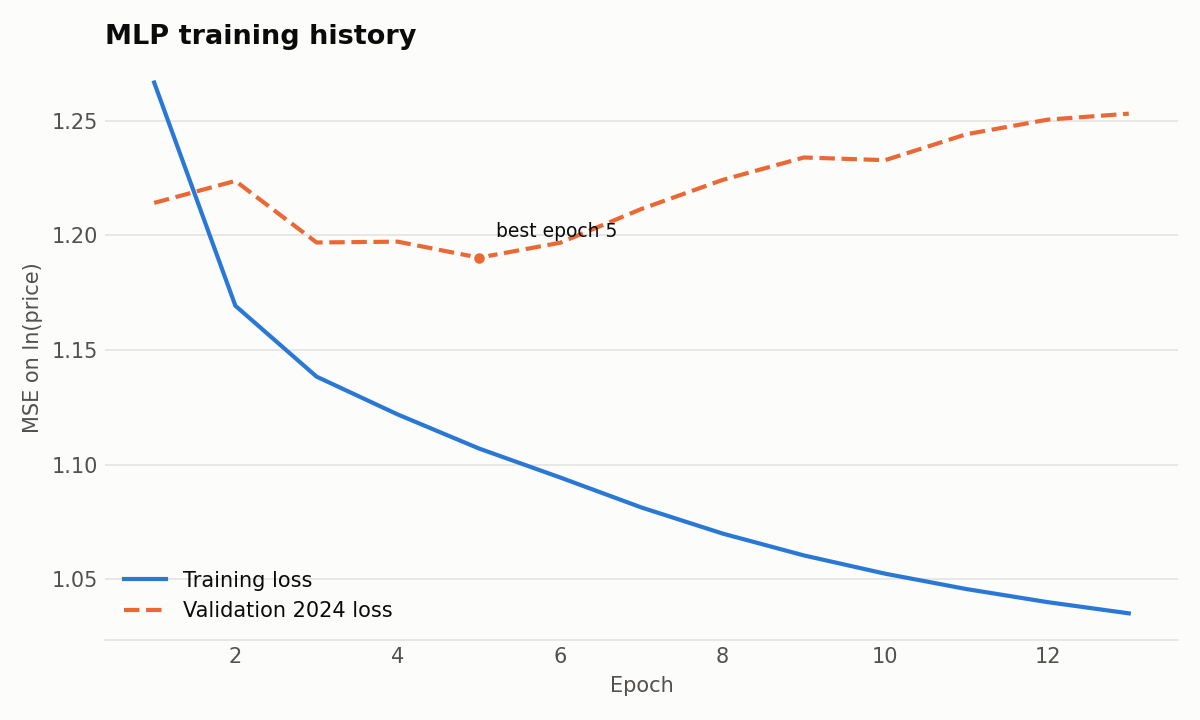

The Initial MLP ran **13 epochs** before early stopping; validation loss was lowest at epoch **5** and those weights were restored.

,epoch,loss,mae,val_loss,val_mae
0,1,1.2666,0.8547,1.2141,0.8232
1,2,1.1693,0.8158,1.2237,0.8282
2,3,1.1383,0.8040,1.1968,0.8130
3,4,1.1218,0.7972,1.1972,0.8132
4,5,1.1070,0.7915,1.1902,0.8118
5,6,1.0944,0.7865,1.1967,0.8212
6,7,1.0813,0.7816,1.2115,0.8340
7,8,1.0699,0.7771,1.2241,0.8406
8,9,1.0604,0.7733,1.2339,0.8452
9,10,1.0524,0.7700,1.2327,0.8459


In [10]:
display(Image(filename=str(FIGS / 'mlp_training_history.png'), width=640))
best_epoch = int(history.loc[history['val_loss'].idxmin(), 'epoch'])
display(Markdown(f"The Initial MLP ran **{len(history)} epochs** before early stopping; validation loss was lowest at epoch **{best_epoch}** and those weights were restored."))
history

## 6. Findings for Initial Modeling

In [11]:
v, t = val.set_index('Model'), test.set_index('Model')
cat, xgb_, mlp, base = 'Initial CatBoost', 'Initial XGBoost', 'Initial MLP', 'Historical Median Baseline'
drift = lambda m: (t.loc[m, 'Test MAE (SAR)'] / v.loc[m, 'Validation MAE (SAR)'] - 1) * 100
display(Markdown(f'''- **{cat}** has the lowest Test MAE ({t.loc[cat, 'Test MAE (SAR)']:,.0f} SAR) and the smallest validation-to-test MAE change ({drift(cat):+.1f}%), versus {drift(xgb_):+.1f}% for {xgb_}: it is the strongest stable individual initial model.
- **{mlp} performed worse than the baseline** in its current configuration (test MAE {t.loc[mlp, 'Test MAE (SAR)']:,.0f} vs {t.loc[base, 'Test MAE (SAR)']:,.0f} SAR). This is reported honestly and is not removed.
- SAR-scale R\u00b2 is strongly influenced by a small number of extreme Commercial transactions (see the Commercial rows in section 4). No outlier audit or data modification has been done.
- Recommended for later hyperparameter tuning (chosen by validation MAE only): {' and '.join(legacy.get(m, m) for m in summary['recommended_for_tuning'])}.
- Full report: `outputs/initial_models/reports/initial_models_report.md`.'''))

- **Initial CatBoost** has the lowest Test MAE (554,819 SAR) and the smallest validation-to-test MAE change (+0.1%), versus +10.5% for Initial XGBoost: it is the strongest stable individual initial model.
- **Initial MLP performed worse than the baseline** in its current configuration (test MAE 1,186,306 vs 679,496 SAR). This is reported honestly and is not removed.
- SAR-scale R² is strongly influenced by a small number of extreme Commercial transactions (see the Commercial rows in section 4). No outlier audit or data modification has been done.
- Recommended for later hyperparameter tuning (chosen by validation MAE only): Initial XGBoost and Initial CatBoost.
- Full report: `outputs/initial_models/reports/initial_models_report.md`.

## 7. Hyperparameter Tuning — Work in Progress

**Not finished.** The tables below are earlier tuning experiments, shown for reference only. They are not initial models and no model has been selected as the outcome of tuning. Details: `outputs/tuning/reports/tuning_work_in_progress.md`.

**Test 2025 note:** Test 2025 was evaluated for the initial models and evaluated again for these experiments, so the tuning Test 2025 numbers are a *second look*, not an untouched holdout. Future tuning decisions must use Training 2020-2023 and Validation 2024 only.

In [12]:
pd.read_csv(TUNE / 'tables/v2_xgboost_validation_experiments.csv')

,min_child_weight,trees_kept,val_mae_sar,val_rmse_sar,val_r2_sar,val_r2_ln_price,train_seconds
0,50,1216,"531,508.8214","7,401,741.9131",0.3129,0.7118,43.2766
1,200,1406,"523,324.5082","7,198,782.9277",0.3501,0.7090,64.5286
2,1000,2684,"541,422.3431","7,646,554.3145",0.2667,0.6989,114.2356


In [13]:
display(Markdown('**Validation 2024 (tuning experiments; v1 rows are the initial models for reference)**'))
display(pd.read_csv(TUNE / 'tables/v2_validation_comparison.csv'))
display(Markdown('**Test 2025 (second look)**'))
display(pd.read_csv(TUNE / 'tables/v2_test_comparison.csv'))

**Validation 2024 (tuning experiments; v1 rows are the initial models for reference)**

,Model,Validation MAE (SAR),Validation RMSE (SAR),Validation R2 (SAR),Validation R2 (ln price),Median abs error (SAR),MAE improvement vs baseline (%)
0,XGBoost v1,"539,630.0420","8,261,631.7250",0.1440,0.7132,"117,989.8532",18.7289
1,CatBoost v1,"554,411.0805","7,638,328.8945",0.2683,0.7019,"130,865.1861",16.5028
2,XGBoost v2 (min_child_weight=200),"523,324.5082","7,198,782.9277",0.3501,0.7090,"118,440.1714",21.1846
3,"Ensemble v2 (XGBoost v2 + CatBoost, 50/50)","523,066.2696","6,801,708.3278",0.4198,0.7190,"119,562.6870",21.2235


**Test 2025 (second look)**

,Model,Test MAE (SAR),Test RMSE (SAR),Test R2 (SAR),Test R2 (ln price),Median abs error (SAR),MAE improvement vs test baseline (%),Met 15% target
0,XGBoost v1,"596,077.3127","12,670,755.7478",-0.7500,0.6497,"130,468.5570",12.2765,No
1,CatBoost v1,"554,819.4782","7,609,559.6728",0.3688,0.6445,"132,480.2527",18.3484,Yes
2,XGBoost v2 (min_child_weight=200),"561,275.7740","8,655,181.9514",0.1835,0.6488,"130,178.5244",17.3982,Yes
3,"Ensemble v2 (XGBoost v2 + CatBoost, 50/50)","545,025.9698","7,647,744.4402",0.3625,0.6604,"128,682.6028",19.7897,Yes


## 8. Limitations
- Initial results are **untuned** starting points.
- Scores in SAR are dominated by a few very expensive transactions; SAR-scale R\u00b2 is unstable.
- 2024-2025 lie beyond the training time range; tree models cannot extrapolate the time index.
- Validation was used for early stopping, so validation scores are slightly optimistic.
- Full methodology: `outputs/initial_models/reports/initial_models_report.md`.